# TMD_BKK_CV1 — seasonal cross-validation for TMD_BKK_V1

[`Thailand_Rain_Seasonal_CV.ipynb`](Thailand_Rain_Seasonal_CV.ipynb) ran this idea on
`OM_THAILAND_DATA_PRECOMPUTE` and closed with an honest caveat:

> Only 12 months exist, so each held-out block is also an unseen season. Degradation
> mixes "harder season" with "season never trained on"; multi-year data is required
> to separate the two.

`BKK_TMD_WEATHER_DATA` spans six and a half years, so that separation is possible here.

| part | held out | the model has... | question it answers |
|---|---|---|---|
| **A** | one calendar **year** | ...seen this season, in other years | how hard is this month, intrinsically? |
| **B** | one calendar **quarter**, in every year | ...never seen this season | what does an unseen season cost? |
| **C** | A vs B on the same rows | — | how much of the seasonal drop is unfamiliarity? |

There is a second reason to run this on `TMD_BKK_V1` specifically. Its saved test metrics
show **negative Brier skill at 1 h and 2 h** — Brier 0.125 against a climatological 0.068,
so the probabilities are worse than always predicting the base rate — and those are exactly
the two horizons whose selected thresholds were driven to 0.85 and 0.80. Per-month
thresholds here show whether 0.85 is a real property of the model or an artefact of which
months happened to land in V1's validation window.

Read-only against the database. Does not overwrite any `TMD_BKK_V1` artefact.

In [1]:
import gc
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Configuration

Copied from `TMD_BKK_V1` so the only moving part is the split scheme.

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"BKK_TMD_WEATHER_DATA"'
SPATIAL_TABLE_NAME = '"BKK_TMD_SPATIAL_FEATURES_100KM"'
KEEP_REGION = "1"  # region 2 has 2 stations / 871 rows and no spatial-feature coverage

PROJECT_ROOT = Path.cwd()
V1_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_bkk_rain_any_final_4_neighbor_models"
OUTPUT_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_bkk_rain_any_seasonal_cv"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
MODEL_PLAN = {1: "lightgbm", 2: "lightgbm", 3: "hist_gradient_boosting", 6: "hist_gradient_boosting"}
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)
RANDOM_STATE = 42
SAMPLE_STATIONS = None  # Example for a quick smoke test: 6

PURGE_HOURS = 24
QUARTERS = {1: [1, 2, 3], 2: [4, 5, 6], 3: [7, 8, 9], 4: [10, 11, 12]}
VOLUME_CONTROL_HORIZON = 1
MIN_FOLD_ROWS = 20_000

# TMD stores UTC. Season is a local-clock idea, so the calendar keys below are built on
# Asia/Bangkok time; the purge still works on the raw UTC stamps, where it is just a delta.
LOCAL_OFFSET = pd.Timedelta(hours=7)


def load_v1_thresholds(path, fallback):
    try:
        meta = json.loads(Path(path).read_text(encoding="utf-8"))
    except FileNotFoundError:
        print(f"{path} not found; using fallback thresholds {fallback}")
        return fallback
    for key in ("selected_probability_thresholds", "probability_thresholds", "thresholds"):
        if key in meta:
            return {int(k): float(v) for k, v in meta[key].items()}
    print(f"No threshold key in {path}; using fallback {fallback}")
    return fallback


V1_THRESHOLDS = load_v1_thresholds(V1_DIR / "final_4_metadata.json",
                                   {1: 0.85, 2: 0.80, 3: 0.30, 6: 0.30})
print(f"Source table   : {TABLE_NAME}")
print(f"V1 thresholds  : {V1_THRESHOLDS}")
print(f"Output         : {OUTPUT_DIR}")

Source table   : "BKK_TMD_WEATHER_DATA"
V1 thresholds  : {3: 0.30000000000000004, 6: 0.30000000000000004, 1: 0.8500000000000002, 2: 0.8000000000000002}
Output         : C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\tmd_bkk_rain_any_seasonal_cv


## 2. Features

The 63 columns of `TMD_BKK_V1`: 11 station observations, 13 derived, 16 lag/rolling,
23 neighbourhood.

In [3]:
STATION_FEATURE_COLUMNS = [
    "latitude", "longitude", "altitude_m",
    "temperature_c", "precipitation_mm", "pressure_hpa", "humidity_percent",
    "wind_speed_avg_knot", "max_wind_speed_knot",
    # ~32% null; passed through as NaN because both learners split on NaN natively.
    "weather_code", "visibility_m",
]

DERIVED_FEATURE_COLUMNS = [
    "wind_dir_avg_sin", "wind_dir_avg_cos", "max_wind_dir_sin", "max_wind_dir_cos",
    "temperature_humidity_index", "temperature_dew_point_spread_est",
    "pressure_hpa_change_3h", "pressure_hpa_change_6h", "humidity_change_3h",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

LAG_FEATURE_COLUMNS = [
    "precipitation_lag_1h", "precipitation_lag_2h", "precipitation_lag_3h", "precipitation_lag_6h",
    "precipitation_sum_past_3h", "precipitation_sum_past_6h",
    "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "temperature_lag_1h", "temperature_lag_3h",
    "humidity_lag_1h", "humidity_lag_3h",
    "pressure_lag_1h", "pressure_lag_3h",
    "wind_speed_lag_1h", "wind_speed_lag_3h",
]

SPATIAL_TABLE_COLUMNS = [
    "nearest_station_distance_km",
    "nearby_station_count_50km", "nearby_station_count_100km", "nearby_station_count_200km",
    "nearby_precip_mean_now_100km", "nearby_precip_max_now_100km",
    "nearby_rain_rate_now_010mm_100km", "nearby_rain_rate_now_025mm_100km",
    "nearby_humidity_mean_now_100km", "nearby_pressure_mean_now_100km",
    "nearby_wind_speed_mean_now_100km",
    "nearby_precip_mean_lag1_100km", "nearby_precip_max_lag1_100km",
    "nearby_rain_rate_lag1_010mm_100km", "nearby_rain_rate_lag1_025mm_100km",
    "nearby_humidity_mean_lag1_100km", "nearby_pressure_mean_lag1_100km",
    "nearby_wind_speed_mean_lag1_100km",
    # ~80-85% null, but the missingness is the signal: NULL means no neighbour within
    # 100 km was raining last hour. Left as NaN so the split itself carries that meaning.
    "nearest_rainy_station_distance_lag1_010mm_km",
    "nearest_rainy_station_distance_lag1_025mm_km",
]

NEIGHBOR_CONTRAST_COLUMNS = [
    "nearby_precip_mean_now_minus_center",
    "nearby_humidity_mean_now_minus_center",
    "center_pressure_minus_nearby_mean",
]

NEIGHBOR_FEATURE_COLUMNS = SPATIAL_TABLE_COLUMNS + NEIGHBOR_CONTRAST_COLUMNS
FEATURE_COLUMNS = (STATION_FEATURE_COLUMNS + DERIVED_FEATURE_COLUMNS
                   + LAG_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS)
TARGET_COLUMNS = [f"rain_any_next_{h}h" for h in HORIZONS]

REQUIRED_NON_NULL_COLUMNS = [
    "temperature_c", "precipitation_mm", "pressure_hpa", "humidity_percent",
    "pressure_hpa_change_6h", "precipitation_lag_6h", "precipitation_sum_past_24h",
    "humidity_lag_3h", "wind_speed_lag_3h", "nearby_precip_mean_lag1_100km",
    f"rain_any_next_{max(HORIZONS)}h",
]
print(f"Features: {len(FEATURE_COLUMNS)}  targets: {TARGET_COLUMNS}")

Features: 63  targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 3. Build the panel

Verbatim from `TMD_BKK_V1` sections 3–4: reindex onto a gap-free hourly grid per station
before any lag or target, NULL the negative-precipitation sentinels rather than clip them,
and require the deepest member of each feature family to be present.

In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_raw_tmd_data(sample_stations=None):
    """Observations LEFT JOINed to their precomputed 100 km neighbourhood features."""
    neighbor_sql = ",\n        ".join(f"spatial.{c}" for c in SPATIAL_TABLE_COLUMNS)
    query = f"""
    SELECT
        weather.utc_time, weather.station, weather.station_name,
        weather.latitude, weather.longitude, weather.altitude_m,
        weather.wind_dir_avg_deg, weather.max_wind_dir_deg,
        weather.wind_speed_avg_knot, weather.max_wind_speed_knot,
        weather.temperature_c,
        -- 62 rows carry sentinel values down to -3174 mm. NULL them rather than clip to 0:
        -- clipping would invent a confident dry observation and a wrong rain_any label.
        CASE WHEN weather.precipitation_mm >= 0 THEN weather.precipitation_mm END AS precipitation_mm,
        weather.pressure_hpa, weather.humidity_percent,
        weather.weather_code, weather.visibility_m,
        {neighbor_sql}
    FROM {TABLE_NAME} weather
    LEFT JOIN {SPATIAL_TABLE_NAME} spatial
      ON spatial.station = weather.station
     AND spatial.utc_time = weather.utc_time
    WHERE weather.utc_time IS NOT NULL
      AND weather.station IS NOT NULL
      AND weather.latitude IS NOT NULL
      AND weather.longitude IS NOT NULL
      AND weather.region = %(region)s
    ORDER BY weather.station, weather.utc_time
    """
    with connect() as conn:
        raw = pd.read_sql_query(query, conn, params={"region": KEEP_REGION},
                                parse_dates=["utc_time"])
    if sample_stations:
        keep = sorted(raw["station"].unique())[:sample_stations]
        raw = raw[raw["station"].isin(keep)].reset_index(drop=True)
    return raw


def to_hourly_panel(raw):
    """Reindex each station onto a gap-free hourly DatetimeIndex.

    TMD coverage is 82%, and the holes are a few hundred *long* outages per station rather
    than scattered single hours. Without this, the row-order shift(6) behind
    precipitation_lag_6h would happily reach across a six-month outage.
    """
    static_columns = ["station_name", "latitude", "longitude", "altitude_m"]
    frames = []
    for station_id, group in raw.groupby("station", sort=True):
        group = group.drop_duplicates("utc_time").set_index("utc_time").sort_index()
        full_index = pd.date_range(group.index.min(), group.index.max(), freq="h")
        group = group.reindex(full_index)
        group.index.name = "forecast_time"
        group["station"] = station_id
        group[static_columns] = group[static_columns].ffill().bfill()
        frames.append(group.reset_index())
    return pd.concat(frames, ignore_index=True)


def angular_sin(series):
    return np.sin(np.deg2rad(series.astype("float64")))


def angular_cos(series):
    return np.cos(np.deg2rad(series.astype("float64")))


def estimate_dew_point_c(temperature_c, humidity_percent):
    """Magnus-Tetens dew point. TMD does not report dew point directly."""
    humidity = humidity_percent.clip(lower=1, upper=100)
    alpha = np.log(humidity / 100.0) + (17.625 * temperature_c) / (243.04 + temperature_c)
    return (243.04 * alpha) / (17.625 - alpha)


def add_derived_features(data):
    data["wind_dir_avg_sin"] = angular_sin(data["wind_dir_avg_deg"])
    data["wind_dir_avg_cos"] = angular_cos(data["wind_dir_avg_deg"])
    data["max_wind_dir_sin"] = angular_sin(data["max_wind_dir_deg"])
    data["max_wind_dir_cos"] = angular_cos(data["max_wind_dir_deg"])
    data["temperature_humidity_index"] = data["temperature_c"] * (data["humidity_percent"] / 100.0)
    dew_point = estimate_dew_point_c(data["temperature_c"], data["humidity_percent"])
    data["temperature_dew_point_spread_est"] = data["temperature_c"] - dew_point

    hour = data["forecast_time"].dt.hour
    month = data["forecast_time"].dt.month
    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    data["month_sin"] = np.sin(2 * np.pi * month / 12)
    data["month_cos"] = np.cos(2 * np.pi * month / 12)

    data["nearby_precip_mean_now_minus_center"] = (
        data["nearby_precip_mean_now_100km"] - data["precipitation_mm"])
    data["nearby_humidity_mean_now_minus_center"] = (
        data["nearby_humidity_mean_now_100km"] - data["humidity_percent"])
    data["center_pressure_minus_nearby_mean"] = (
        data["pressure_hpa"] - data["nearby_pressure_mean_now_100km"])
    return data


def add_lag_features(data):
    """Backward-looking features. Shifting by rows is safe because the panel is gap-free."""
    grouped = data.groupby("station", group_keys=False)

    data["pressure_hpa_change_3h"] = grouped["pressure_hpa"].diff(3)
    data["pressure_hpa_change_6h"] = grouped["pressure_hpa"].diff(6)
    data["humidity_change_3h"] = grouped["humidity_percent"].diff(3)

    lag_specs = {
        "precipitation_lag_1h": ("precipitation_mm", 1),
        "precipitation_lag_2h": ("precipitation_mm", 2),
        "precipitation_lag_3h": ("precipitation_mm", 3),
        "precipitation_lag_6h": ("precipitation_mm", 6),
        "temperature_lag_1h": ("temperature_c", 1),
        "temperature_lag_3h": ("temperature_c", 3),
        "humidity_lag_1h": ("humidity_percent", 1),
        "humidity_lag_3h": ("humidity_percent", 3),
        "pressure_lag_1h": ("pressure_hpa", 1),
        "pressure_lag_3h": ("pressure_hpa", 3),
        "wind_speed_lag_1h": ("wind_speed_avg_knot", 1),
        "wind_speed_lag_3h": ("wind_speed_avg_knot", 3),
    }
    for output_column, (source_column, lag) in lag_specs.items():
        data[output_column] = grouped[source_column].shift(lag)

    # min_periods == window, so a rolling total spanning an outage stays NaN instead of
    # silently under-counting the hours it could not see.
    for hours in [3, 6, 12, 24]:
        data[f"precipitation_sum_past_{hours}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=hours: s.shift(1).rolling(window, min_periods=window).sum()
        )
    return data


def add_targets(data):
    """rain_any_next_Nh: did the station gauge record >= RAIN_THRESHOLD_MM in any of the
    next N hours. NaN whenever any hour of that window is unobserved."""

    def future_rain_any(series, window):
        future_max = (
            series.shift(-1).rolling(window, min_periods=window).max().shift(-(window - 1))
        )
        return pd.Series(
            np.where(future_max.notna(), (future_max >= RAIN_THRESHOLD_MM).astype("float"), np.nan),
            index=series.index,
        )

    grouped = data.groupby("station", group_keys=False)
    for horizon in HORIZONS:
        data[f"rain_any_next_{horizon}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=horizon: future_rain_any(s, window)
        )
    return data


def read_training_data(sample_stations=None):
    raw = read_raw_tmd_data(sample_stations)
    print(f"raw observations : {len(raw):,} rows, {raw['station'].nunique()} stations")

    panel = to_hourly_panel(raw)
    inserted = len(panel) - len(raw)
    print(f"hourly panel     : {len(panel):,} rows "
          f"({inserted:,} NaN spacers inserted, {inserted / len(panel):.1%} of the grid)")

    panel = add_derived_features(panel)
    panel = add_lag_features(panel)
    panel = add_targets(panel)

    complete = panel.dropna(subset=REQUIRED_NON_NULL_COLUMNS).copy()
    complete = complete[complete["nearby_station_count_100km"] > 0]
    complete[TARGET_COLUMNS] = complete[TARGET_COLUMNS].astype("int8")
    complete = complete.sort_values(["forecast_time", "station"]).reset_index(drop=True)
    print(f"modelling rows   : {len(complete):,} "
          f"({len(complete) / len(panel):.1%} of the hourly grid survive the non-null filter)")
    return complete


started = time.time()
model_df = read_training_data(SAMPLE_STATIONS)

x_all = np.ascontiguousarray(model_df[FEATURE_COLUMNS].to_numpy(dtype="float32"))
y_all = model_df[TARGET_COLUMNS].to_numpy(dtype="int8")
forecast_time = model_df["forecast_time"].to_numpy(dtype="datetime64[s]")
unit_id = model_df["station"].to_numpy()

print(f"\nLoaded in {(time.time()-started)/60:.1f} min   x: {x_all.shape}  "
      f"({x_all.nbytes/1e9:.2f} GB)")
print(f"{forecast_time.min()} .. {forecast_time.max()} UTC   stations: {np.unique(unit_id).size}")

C:\Users\Brandon\AppData\Local\Temp\ipykernel_35484\2932231327.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw = pd.read_sql_query(query, conn, params={"region": KEEP_REGION},


raw observations : 1,005,080 rows, 26 stations


hourly panel     : 1,225,594 rows (220,514 NaN spacers inserted, 18.0% of the grid)


modelling rows   : 902,356 (73.6% of the hourly grid survive the non-null filter)



Loaded in 0.6 min   x: (902356, 63)  (0.23 GB)


2020-01-02T01:00:00 .. 2026-06-24T03:00:00 UTC   stations: 26


In [5]:
stamps = pd.to_datetime(forecast_time) + LOCAL_OFFSET   # season is a local-clock idea
year_key = stamps.year.to_numpy()
month_of_year = stamps.month.to_numpy()
month_key = pd.PeriodIndex(stamps, freq="M").astype(str).to_numpy()
quarter_key = np.select([np.isin(month_of_year, m) for m in QUARTERS.values()],
                        list(QUARTERS.keys()))
unique_months = sorted(pd.unique(month_key))

print(f"{len(unique_months)} months: {unique_months[0]} .. {unique_months[-1]}")
display(pd.DataFrame({
    "year": year_key, "rain_1h": y_all[:, 0], "rain_6h": y_all[:, 3],
}).groupby("year").agg(rows=("rain_1h", "size"), rain_rate_1h=("rain_1h", "mean"),
                       rain_rate_6h=("rain_6h", "mean")))

70 months: 2020-01 .. 2026-06


,rows,rain_rate_1h,rain_rate_6h
year,,,
2020,106491,0.0446,0.1259
2021,75064,0.0439,0.1165
2022,127661,0.0511,0.1453
2023,165981,0.0525,0.1440
2024,203879,0.0508,0.1399
2025,205714,0.0567,0.1600
2026,17566,0.0704,0.2226


## 4. Fold construction

`purged_train_mask` drops any training row within `PURGE_HOURS` of *any* held-out
timestamp, working off unique timestamps rather than row positions — each hour appears
once per station, so dilating by row count would purge 26x too little.

In [6]:
PURGE = np.timedelta64(PURGE_HOURS, "h")


def purged_train_mask(test_mask, times=forecast_time, purge=PURGE):
    """Training rows: not held out, and not within `purge` of any held-out timestamp."""
    test_times = np.unique(times[test_mask])
    position = np.searchsorted(test_times, times)
    left = test_times[np.clip(position - 1, 0, len(test_times) - 1)]
    right = test_times[np.clip(position, 0, len(test_times) - 1)]
    distance = np.minimum(np.abs(times - left), np.abs(times - right))
    return ~test_mask & (distance > purge)


candidate_years = [int(y) for y in np.unique(year_key)]
YEAR_FOLDS = [y for y in candidate_years if (year_key == y).sum() >= MIN_FOLD_ROWS]
dropped = sorted(set(candidate_years) - set(YEAR_FOLDS))
if dropped:
    print(f"Years too small to be a fold (kept in training only): {dropped}")

fold_rows = []
for year in YEAR_FOLDS:
    test_mask = year_key == year
    train_mask = purged_train_mask(test_mask)
    fold_rows.append({"part": "A_year", "fold": str(year), "test_rows": int(test_mask.sum()),
                      "train_rows": int(train_mask.sum()),
                      "purged_rows": int(len(forecast_time) - test_mask.sum() - train_mask.sum()),
                      "test_rain_rate_1h": float(y_all[test_mask, 0].mean())})
for quarter, month_list in QUARTERS.items():
    test_mask = quarter_key == quarter
    train_mask = purged_train_mask(test_mask)
    fold_rows.append({"part": "B_quarter", "fold": f"Q{quarter} {month_list}",
                      "test_rows": int(test_mask.sum()), "train_rows": int(train_mask.sum()),
                      "purged_rows": int(len(forecast_time) - test_mask.sum() - train_mask.sum()),
                      "test_rain_rate_1h": float(y_all[test_mask, 0].mean())})

fold_table = pd.DataFrame(fold_rows)
display(fold_table)

mean_train_a = fold_table.loc[fold_table["part"] == "A_year", "train_rows"].mean()
mean_train_b = fold_table.loc[fold_table["part"] == "B_quarter", "train_rows"].mean()
print(f"Part A trains on a mean {mean_train_a:,.0f} rows, Part B on {mean_train_b:,.0f} "
      f"({mean_train_a / mean_train_b - 1:+.1%}) — section 6 controls for the difference.")

Years too small to be a fold (kept in training only): [2026]


,part,fold,test_rows,train_rows,purged_rows,test_rain_rate_1h
0,A_year,2020,106491,795457,408,0.0446
1,A_year,2021,75064,826476,816,0.0439
2,A_year,2022,127661,773903,792,0.0511
3,A_year,2023,165981,735454,921,0.0525
4,A_year,2024,203879,697318,1159,0.0508
5,A_year,2025,205714,695992,650,0.0567
6,B_quarter,"Q1 [1, 2, 3]",209205,688135,5016,0.0079
7,B_quarter,"Q2 [4, 5, 6]",219141,678962,4253,0.0542
8,B_quarter,"Q3 [7, 8, 9]",223661,674377,4318,0.1048
9,B_quarter,"Q4 [10, 11, 12]",250349,647025,4982,0.0382


Part A trains on a mean 754,100 rows, Part B on 672,125 (+12.2%) — section 6 controls for the difference.


## 5. Run both CV parts

In [7]:
def fit_predict(x_train, y_train, x_test, model_name):
    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary", n_estimators=500, learning_rate=0.04, num_leaves=63,
            min_child_samples=80, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1,
        )
    else:
        model = HistGradientBoostingClassifier(
            learning_rate=0.06, max_iter=250, max_leaf_nodes=31,
            l2_regularization=0.05, random_state=RANDOM_STATE, early_stopping=False,
        )
    model.fit(x_train, y_train)
    probabilities = model.predict_proba(x_test)[:, 1].astype("float32")
    del model
    gc.collect()
    return probabilities


def run_cv(fold_masks, label):
    """fold_masks: list of (fold_name, test_mask). Returns OOF probabilities + a log."""
    oof = np.full((x_all.shape[0], len(HORIZONS)), np.nan, dtype="float32")
    log = []
    started_all = time.time()
    for fold_name, test_mask in fold_masks:
        train_mask = purged_train_mask(test_mask)
        x_train, x_test = x_all[train_mask], x_all[test_mask]
        print(f"\n=== {label} fold {fold_name}: test {test_mask.sum():,}, "
              f"train {train_mask.sum():,} ===", flush=True)
        for horizon_index, horizon in enumerate(HORIZONS):
            model_name = MODEL_PLAN[horizon]
            started = time.time()
            oof[test_mask, horizon_index] = fit_predict(
                x_train, y_all[train_mask, horizon_index], x_test, model_name)
            elapsed = time.time() - started
            log.append({"part": label, "fold": fold_name, "horizon_h": horizon,
                        "model": model_name, "train_rows": int(train_mask.sum()),
                        "test_rows": int(test_mask.sum()), "fit_seconds": elapsed})
            print(f"  {horizon}h {model_name}: {elapsed/60:.1f} min", flush=True)
        del x_train, x_test
        gc.collect()
    print(f"\n{label} finished in {(time.time()-started_all)/60:.1f} min; "
          f"coverage {np.isfinite(oof).all(axis=1).mean():.4f}")
    return oof, log


oof_a, log_a = run_cv([(str(y), year_key == y) for y in YEAR_FOLDS], "A_year")
oof_b, log_b = run_cv([(f"Q{q}", quarter_key == q) for q in QUARTERS], "B_quarter")

fold_log = pd.DataFrame(log_a + log_b)
display(fold_log.groupby(["part", "horizon_h"])["fit_seconds"].agg(["count", "mean", "sum"]))


=== A_year fold 2020: test 106,491, train 795,457 ===


  1h lightgbm: 0.3 min


  2h lightgbm: 0.3 min


  3h hist_gradient_boosting: 0.3 min


  6h hist_gradient_boosting: 0.3 min


...

  2h lightgbm: 0.3 min


  3h hist_gradient_boosting: 0.3 min


  6h hist_gradient_boosting: 0.2 min



B_quarter finished in 4.5 min; coverage 1.0000


count    mean      sum
part      horizon_h                        
A_year    1              6 22.1890 133.1340
          2              6 19.1082 114.6492
          3              6 16.5970  99.5822
          6              6 23.3586 140.1517
B_quarter 1              4 14.3460  57.3841
          2              4 20.0671  80.2682
          3              4 15.0639  60.2556
          6              4 17.1936  68.7746

## 6. Volume control

Part A trains on more rows than Part B, so a raw A-vs-B gap conflates "saw the season"
with "saw more data". This rerun gives Part A the same number of training rows as the
matching Part B fold, sampled at random.

In [8]:
target_train_rows = int(np.mean([m["train_rows"] for m in fold_rows if m["part"] == "B_quarter"]))
horizon_index_vc = HORIZONS.index(VOLUME_CONTROL_HORIZON)
rng = np.random.default_rng(RANDOM_STATE)

oof_a_matched = np.full(x_all.shape[0], np.nan, dtype="float32")
control_log = []
for year in YEAR_FOLDS:
    test_mask = year_key == year
    train_mask = purged_train_mask(test_mask)
    train_index = np.flatnonzero(train_mask)
    if len(train_index) > target_train_rows:
        train_index = np.sort(rng.choice(train_index, target_train_rows, replace=False))
    started = time.time()
    oof_a_matched[test_mask] = fit_predict(
        x_all[train_index], y_all[train_index, horizon_index_vc],
        x_all[test_mask], MODEL_PLAN[VOLUME_CONTROL_HORIZON])
    control_log.append({"fold": str(year), "train_rows": len(train_index),
                        "fit_seconds": time.time() - started})
    print(f"  control {year}: {len(train_index):,} rows, "
          f"{(time.time()-started)/60:.1f} min", flush=True)
display(pd.DataFrame(control_log))

  control 2020: 672,124 rows, 0.2 min


  control 2021: 672,124 rows, 0.3 min


  control 2022: 672,124 rows, 0.2 min


  control 2023: 672,124 rows, 0.2 min


  control 2024: 672,124 rows, 0.2 min


  control 2025: 672,124 rows, 0.2 min


,fold,train_rows,fit_seconds
0,2020,672124,12.8852
1,2021,672124,20.0204
2,2022,672124,13.1849
3,2023,672124,13.2829
4,2024,672124,13.3464
5,2025,672124,13.2349


## 7. Per-month metrics

`brier_skill` is the number to watch: `1 - brier / (p*(1-p))`, so 0 means no better than
always predicting that month's base rate and negative means worse. V1's saved 1 h Brier
of 0.125 sits against a climatology of 0.068, i.e. a skill of -0.83.

In [9]:
def month_metrics(month, horizon_index, horizon, oof, part):
    mask = (month_key == month) & np.isfinite(oof[:, horizon_index])
    if not mask.any():
        return None
    y_true = y_all[mask, horizon_index]
    probabilities = oof[mask, horizon_index]
    row = {"part": part, "month": month, "horizon_h": horizon, "model": MODEL_PLAN[horizon],
           "rows": int(mask.sum()), "rain_rate": float(y_true.mean())}

    if y_true.min() == y_true.max():           # degenerate month, AUC undefined
        row.update({"roc_auc": np.nan, "pr_auc": np.nan, "brier_score": np.nan})
    else:
        row.update({"roc_auc": float(roc_auc_score(y_true, probabilities)),
                    "pr_auc": float(average_precision_score(y_true, probabilities)),
                    "brier_score": float(brier_score_loss(y_true, probabilities))})
    base = float(y_true.mean())
    climatology = base * (1 - base)
    row["brier_climatology"] = climatology
    row["brier_skill"] = (1 - row["brier_score"] / climatology
                          if climatology and np.isfinite(row.get("brier_score", np.nan))
                          else np.nan)

    threshold = V1_THRESHOLDS[horizon]
    y_pred = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    row.update({"v1_threshold": threshold,
                "precision": float(precision_score(y_true, y_pred, zero_division=0)),
                "recall": float(recall_score(y_true, y_pred, zero_division=0)),
                "f1": float(f1_score(y_true, y_pred, zero_division=0)),
                "predicted_rain_rate": float(y_pred.mean()),
                "false_positives": int(fp), "false_negatives": int(fn)})

    best_f1, best_threshold = -1.0, np.nan
    for candidate in PROBABILITY_THRESHOLDS_TO_TEST:
        score = f1_score(y_true, (probabilities >= candidate).astype("int8"), zero_division=0)
        if score > best_f1:
            best_f1, best_threshold = float(score), float(candidate)
    row.update({"best_f1": best_f1, "best_threshold": best_threshold,
                "f1_lost_to_fixed_threshold": best_f1 - row["f1"]})
    return row


monthly = pd.DataFrame([
    r for i, horizon in enumerate(HORIZONS) for month in unique_months
    for r in [month_metrics(month, i, horizon, oof_a, "A_year")] if r
]).sort_values(["horizon_h", "month"])

for horizon in HORIZONS:
    print(f"\n===== {horizon}h ({MODEL_PLAN[horizon]}) — Part A, out-of-fold by month =====")
    print(monthly[monthly["horizon_h"] == horizon][
        ["month", "rows", "rain_rate", "roc_auc", "pr_auc", "brier_score", "brier_skill",
         "precision", "recall", "f1", "best_f1", "best_threshold"]].to_string(index=False))


===== 1h (lightgbm) — Part A, out-of-fold by month =====
  month  rows  rain_rate  roc_auc  pr_auc  brier_score  brier_skill  precision  recall     f1  best_f1  best_threshold
2020-01  8317     0.0010   0.6979  0.0048       0.0025      -1.5769     0.0000  0.0000 0.0000   0.0222          0.1500
2020-02  8240     0.0013   0.7249  0.0460       0.0023      -0.7620     0.0000  0.0000 0.0000   0.1905          0.5000
2020-03  8713     0.0084   0.8914  0.5275       0.0117      -0.4126     0.6094  0.5342 0.5693   0.5806          0.9000
2020-04  8137     0.0163   0.8856  0.3678       0.0278      -0.7279     0.5670  0.4135 0.4783   0.4783          0.8500
2020-05  8183     0.0436   0.8780  0.4693       0.0810      -0.9422     0.5952  0.4202 0.4926   0.4926          0.8500
2020-06  7694     0.0786   0.8872  0.6085       0.1246      -0.7195     0.6066  0.5504 0.5771   0.5774          0.9000
2020-07  8066     0.0646   0.8675  0.5143       0.1278      -1.1159     0.5563  0.5125 0.5335   0.5335       

## 8. Part C — what does an unseen season cost?

In [10]:
def by_calendar_month(oof, part):
    rows = []
    for horizon_index, horizon in enumerate(HORIZONS):
        for m in range(1, 13):
            mask = (month_of_year == m) & np.isfinite(oof[:, horizon_index])
            if not mask.any():
                continue
            y_true = y_all[mask, horizon_index]
            if y_true.min() == y_true.max():
                continue
            rows.append({"part": part, "calendar_month": m, "horizon_h": horizon,
                         "rows": int(mask.sum()), "rain_rate": float(y_true.mean()),
                         "roc_auc": float(roc_auc_score(y_true, oof[mask, horizon_index])),
                         "pr_auc": float(average_precision_score(y_true, oof[mask, horizon_index]))})
    return pd.DataFrame(rows)


calendar = pd.concat([by_calendar_month(oof_a, "A_seen"), by_calendar_month(oof_b, "B_unseen")])
contrast = calendar.pivot_table(index=["horizon_h", "calendar_month"],
                                columns="part", values=["roc_auc", "pr_auc"]).reset_index()
contrast.columns = ["_".join(c).strip("_") for c in contrast.columns]
contrast["roc_auc_cost_of_unseen"] = contrast["roc_auc_A_seen"] - contrast["roc_auc_B_unseen"]
contrast["pr_auc_cost_of_unseen"] = contrast["pr_auc_A_seen"] - contrast["pr_auc_B_unseen"]

print("=== Cost of holding out the whole season (positive = unseen season is worse) ===")
print(contrast.to_string(index=False))
print("\n=== Mean cost by horizon ===")
print(contrast.groupby("horizon_h")[["roc_auc_cost_of_unseen", "pr_auc_cost_of_unseen"]]
      .agg(["mean", "max"]).to_string())

=== Cost of holding out the whole season (positive = unseen season is worse) ===
 horizon_h  calendar_month  pr_auc_A_seen  pr_auc_B_unseen  roc_auc_A_seen  roc_auc_B_unseen  roc_auc_cost_of_unseen  pr_auc_cost_of_unseen
         1               1         0.3388           0.3321          0.9212            0.9181                  0.0030                 0.0067
         1               2         0.4126           0.4227          0.9368            0.9391                 -0.0023                -0.0102
         1               3         0.4694           0.4743          0.9398            0.9444                 -0.0047                -0.0049
         1               4         0.4906           0.4829          0.9253            0.9238                  0.0016                 0.0077
         1               5         0.5747           0.5585          0.8989            0.8905                  0.0085                 0.0163
         1               6         0.5665           0.5650          0.9017     

In [11]:
vc_mask = np.isfinite(oof_a_matched)
vc_rows = []
for m in range(1, 13):
    mask = vc_mask & (month_of_year == m)
    y_true = y_all[mask, horizon_index_vc]
    if not mask.any() or y_true.min() == y_true.max():
        continue
    vc_rows.append({"calendar_month": m,
                    "A_seen_full": float(roc_auc_score(y_true, oof_a[mask, horizon_index_vc])),
                    "A_seen_matched": float(roc_auc_score(y_true, oof_a_matched[mask])),
                    "B_unseen": float(roc_auc_score(y_true, oof_b[mask, horizon_index_vc]))})
volume_control = pd.DataFrame(vc_rows)
volume_control["cost_of_unseen_volume_matched"] = (
    volume_control["A_seen_matched"] - volume_control["B_unseen"])
volume_control["cost_of_volume_alone"] = (
    volume_control["A_seen_full"] - volume_control["A_seen_matched"])

print(f"=== Volume control at {VOLUME_CONTROL_HORIZON}h "
      f"(Part A retrained on {target_train_rows:,} rows to match Part B) ===")
print(volume_control.to_string(index=False))
print("\nmean cost of unseen season, volume-matched: "
      f"{volume_control['cost_of_unseen_volume_matched'].mean():.4f}")
print(f"mean cost of the extra training volume alone : "
      f"{volume_control['cost_of_volume_alone'].mean():.4f}")

=== Volume control at 1h (Part A retrained on 672,124 rows to match Part B) ===
 calendar_month  A_seen_full  A_seen_matched  B_unseen  cost_of_unseen_volume_matched  cost_of_volume_alone
              1       0.9212          0.9294    0.9181                         0.0113               -0.0082
              2       0.9368          0.9373    0.9391                        -0.0018               -0.0005
              3       0.9398          0.9389    0.9444                        -0.0055                0.0009
              4       0.9253          0.9238    0.9238                         0.0000                0.0015
              5       0.8989          0.8992    0.8973                         0.0019               -0.0002
              6       0.9017          0.9017    0.8991                         0.0025                0.0000
              7       0.8946          0.8945    0.8949                        -0.0004                0.0001
              8       0.8982          0.8988    0.8960  

## 9. Versus the V1 headline

In [12]:
v1_metrics = pd.read_csv(V1_DIR / "final_4_metrics.csv")
v1_test = v1_metrics[v1_metrics["split"] == "test"].set_index("horizon_h")
v1_selected = pd.read_csv(V1_DIR / "final_4_selected_threshold_metrics.csv").set_index("horizon_h")

summary = []
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    cost = contrast[contrast["horizon_h"] == horizon]["roc_auc_cost_of_unseen"]
    v1_base = float(v1_test.loc[horizon, "rain_rate"])
    v1_brier = float(v1_test.loc[horizon, "brier_score"])
    summary.append({
        "horizon_h": horizon,
        "V1_headline_roc_auc": float(v1_test.loc[horizon, "roc_auc"]),
        "V1_test_rain_rate": v1_base,
        "V1_brier_skill": 1 - v1_brier / (v1_base * (1 - v1_base)),
        "CV_mean_roc_auc": float(sub["roc_auc"].mean()),
        "CV_worst_month_roc_auc": float(sub["roc_auc"].min()),
        "CV_worst_month": sub.loc[sub["roc_auc"].idxmin(), "month"],
        "V1_headline_f1": float(v1_selected.loc[horizon, "f1"]),
        "CV_mean_f1": float(sub["f1"].mean()),
        "CV_worst_month_f1": float(sub["f1"].min()),
        "f1_spread": float(sub["f1"].max() - sub["f1"].min()),
        "best_threshold_min": float(sub["best_threshold"].min()),
        "best_threshold_max": float(sub["best_threshold"].max()),
        "CV_mean_brier_skill": float(sub["brier_skill"].mean()),
        "mean_cost_of_unseen_season_roc": float(cost.mean()),
    })
summary = pd.DataFrame(summary)
display(summary)

print("""
Interpretation
- V1_headline_* come from the single chronological test split.
- V1_brier_skill vs CV_mean_brier_skill: if both are negative the probability inflation is
  a property of the model (scale_pos_weight), not of which months V1 happened to test on.
- best_threshold_min/max show how far the ideal operating point drifts across seasons; a
  wide range means V1's single 0.85 / 0.80 choice cannot be right for most of the year.
- mean_cost_of_unseen_season_roc is Part A minus Part B: the ROC-AUC specifically
  attributable to having trained on that season before. Thailand could not measure this.
""")

,horizon_h,V1_headline_roc_auc,V1_test_rain_rate,V1_brier_skill,CV_mean_roc_auc,CV_worst_month_roc_auc,CV_worst_month,V1_headline_f1,CV_mean_f1,CV_worst_month_f1,f1_spread,best_threshold_min,best_threshold_max,CV_mean_brier_skill,mean_cost_of_unseen_season_roc
0,1,0.8988,0.0734,-0.8320,0.8994,0.6305,2025-01,0.5622,0.4867,0.0000,0.6667,0.1000,0.9000,-1.0323,0.0016
1,2,0.8691,0.1075,-0.6255,0.8729,0.6377,2020-01,0.5328,0.4470,0.0000,0.6241,0.1000,0.9000,-0.8295,0.0012
2,3,0.8486,0.1364,0.2879,0.8501,0.6289,2020-02,0.5229,0.4215,0.0000,0.6332,0.1000,0.5000,0.2213,0.0006
3,6,0.8156,0.2084,0.2498,0.8135,0.5747,2020-02,0.5325,0.4015,0.0000,0.6600,0.1000,0.3500,0.1771,-0.0012



Interpretation
- V1_headline_* come from the single chronological test split.
- V1_brier_skill vs CV_mean_brier_skill: if both are negative the probability inflation is
  a property of the model (scale_pos_weight), not of which months V1 happened to test on.
- best_threshold_min/max show how far the ideal operating point drifts across seasons; a
  wide range means V1's single 0.85 / 0.80 choice cannot be right for most of the year.
- mean_cost_of_unseen_season_roc is Part A minus Part B: the ROC-AUC specifically
  attributable to having trained on that season before. Thailand could not measure this.



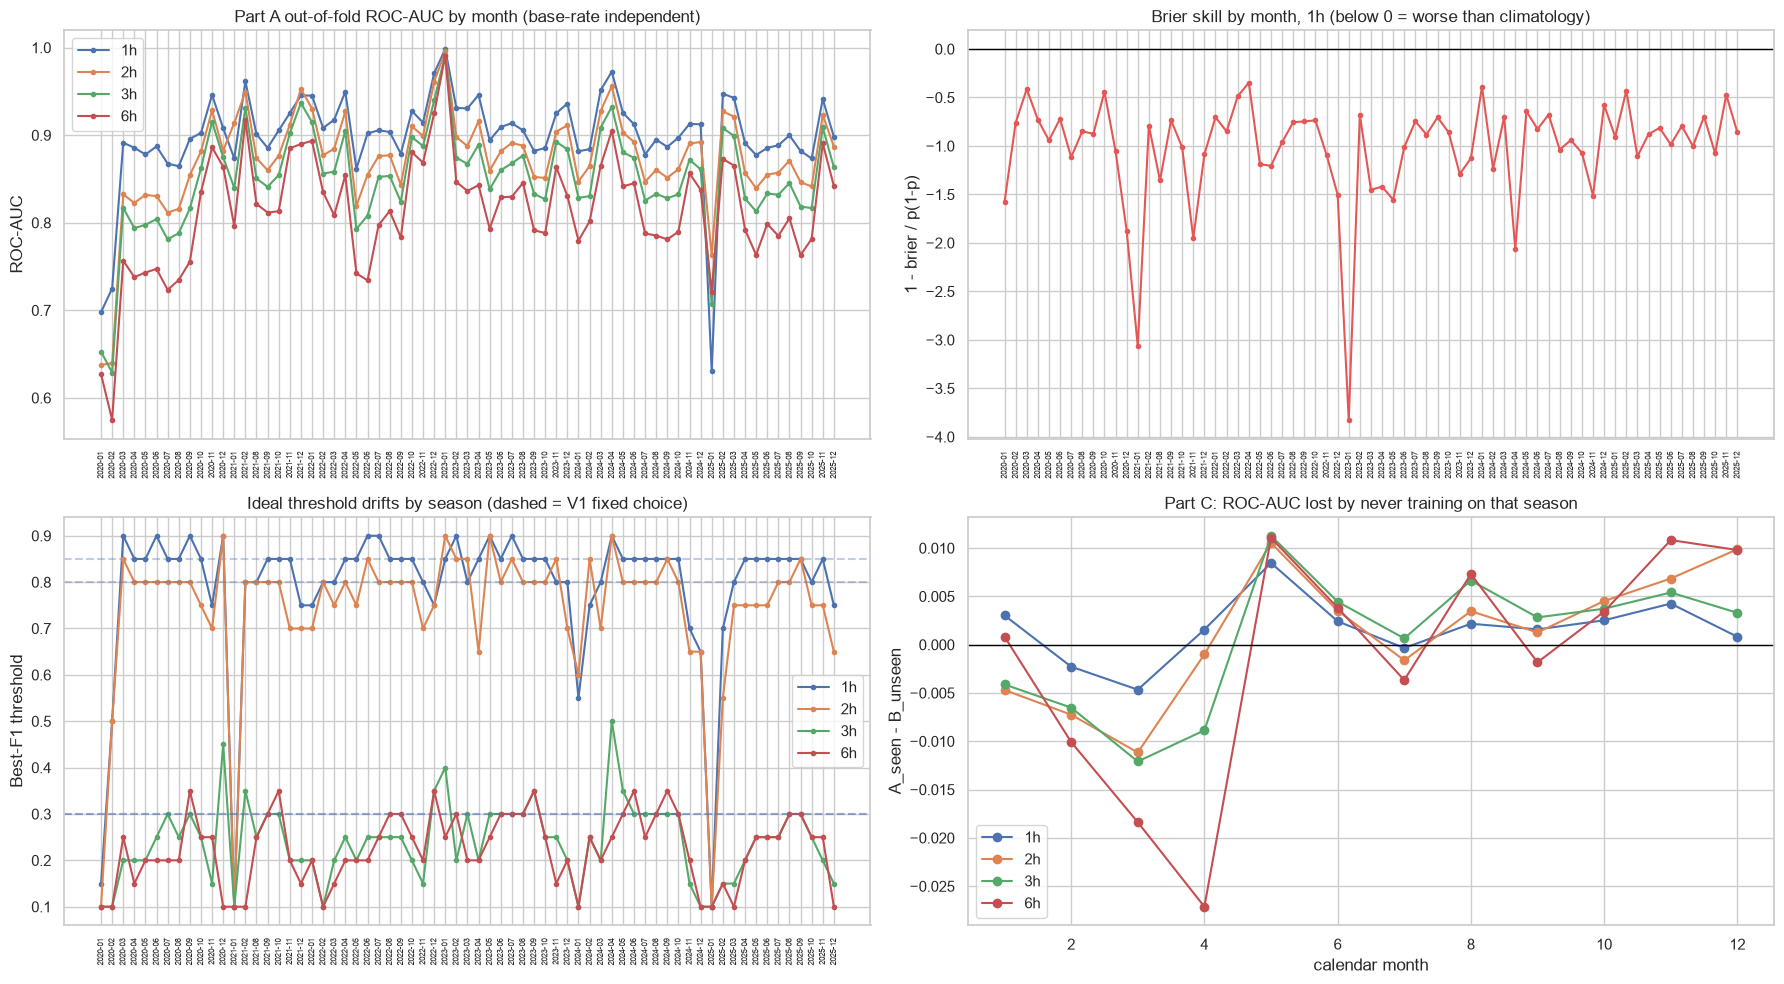

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax = axes[0][0]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["roc_auc"], marker="o", ms=3, label=f"{horizon}h")
ax.set_title("Part A out-of-fold ROC-AUC by month (base-rate independent)")
ax.set_ylabel("ROC-AUC"); ax.legend(); ax.tick_params(axis="x", rotation=90, labelsize=6)

ax = axes[0][1]
sub1 = monthly[monthly["horizon_h"] == 1]
ax.plot(sub1["month"], sub1["brier_skill"], marker="o", ms=3, color="#e45756")
ax.axhline(0, color="black", lw=1)
ax.set_title("Brier skill by month, 1h (below 0 = worse than climatology)")
ax.set_ylabel("1 - brier / p(1-p)"); ax.tick_params(axis="x", rotation=90, labelsize=6)

ax = axes[1][0]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["best_threshold"], marker="o", ms=3, label=f"{horizon}h")
    ax.axhline(V1_THRESHOLDS[horizon], linestyle="--", alpha=0.35)
ax.set_title("Ideal threshold drifts by season (dashed = V1 fixed choice)")
ax.set_ylabel("Best-F1 threshold"); ax.legend(); ax.tick_params(axis="x", rotation=90, labelsize=6)

ax = axes[1][1]
for horizon in HORIZONS:
    sub = contrast[contrast["horizon_h"] == horizon]
    ax.plot(sub["calendar_month"], sub["roc_auc_cost_of_unseen"], marker="o", label=f"{horizon}h")
ax.axhline(0, color="black", lw=1)
ax.set_title("Part C: ROC-AUC lost by never training on that season")
ax.set_xlabel("calendar month"); ax.set_ylabel("A_seen - B_unseen"); ax.legend()

plt.tight_layout()
plt.show()

## 10. Save

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
monthly.to_csv(OUTPUT_DIR / "seasonal_cv_monthly_metrics.csv", index=False)
summary.to_csv(OUTPUT_DIR / "seasonal_cv_summary_vs_v1.csv", index=False)
fold_log.to_csv(OUTPUT_DIR / "seasonal_cv_fold_log.csv", index=False)
fold_table.to_csv(OUTPUT_DIR / "seasonal_cv_folds.csv", index=False)
contrast.to_csv(OUTPUT_DIR / "seasonal_cv_seen_vs_unseen.csv", index=False)
volume_control.to_csv(OUTPUT_DIR / "seasonal_cv_volume_control.csv", index=False)

metadata = {
    "purpose": ("year-blocked and season-blocked CV; separates 'harder season' from "
                "'season never trained on', which Thailand_Rain_Seasonal_CV could not"),
    "source_table": TABLE_NAME,
    "spatial_table": SPATIAL_TABLE_NAME,
    "rows": int(x_all.shape[0]),
    "span_utc": [str(forecast_time.min()), str(forecast_time.max())],
    "local_offset_hours": 7,
    "purge_hours": PURGE_HOURS,
    "part_a_year_folds": [str(y) for y in YEAR_FOLDS],
    "part_b_quarter_folds": {str(q): m for q, m in QUARTERS.items()},
    "volume_control_horizon": VOLUME_CONTROL_HORIZON,
    "volume_control_train_rows": int(target_train_rows),
    "model_plan": MODEL_PLAN,
    "v1_thresholds_used": V1_THRESHOLDS,
    "oof_coverage_a": float(np.isfinite(oof_a).all(axis=1).mean()),
    "oof_coverage_b": float(np.isfinite(oof_b).all(axis=1).mean()),
    "summary_vs_v1": summary.to_dict(orient="records"),
    "mean_cost_of_unseen_season_roc_by_horizon": contrast.groupby("horizon_h")[
        "roc_auc_cost_of_unseen"].mean().to_dict(),
    "caveat": ("Part A and Part B train on different row counts; section 6 measures that "
               "confound at 1h only. Labels are the TMD station gauge, a point measurement: "
               "two gauges 8 km apart agree on rainy hours at only CSI 0.45, so there is a "
               "hard ceiling here that no split scheme can lift."),
}
(OUTPUT_DIR / "seasonal_cv_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(f"Saved seasonal CV results to {OUTPUT_DIR}")

Saved seasonal CV results to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\tmd_bkk_rain_any_seasonal_cv
